<a href="https://colab.research.google.com/github/chrisampiah/Content/blob/main/Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os

file_path = '/content/drive/MyDrive/Training_001_t1.nii'

print("File exists:", os.path.exists(file_path))

File exists: True


In [17]:
!pip install nibabel

import nibabel as nib

# Load MRI scan (example: T1)
file_path = "/content/drive/MyDrive/Training_001_t1.nii"

img = nib.load(file_path)
data = img.get_fdata()

print("Shape:", data.shape)   # (H, W, D)
print("Datatype:", data.dtype)

Shape: (240, 240, 155)
Datatype: float64


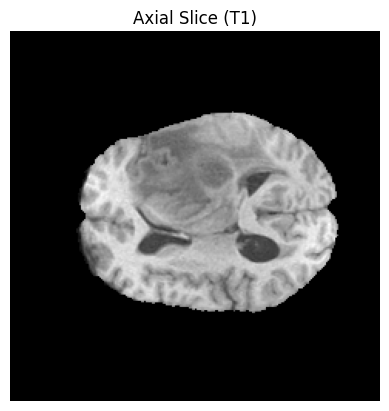

In [18]:
import matplotlib.pyplot as plt

slice_idx = data.shape[2] // 2  # middle slice

plt.imshow(data[:, :, slice_idx], cmap='gray')
plt.title("Axial Slice (T1)")
plt.axis('off')
plt.show()

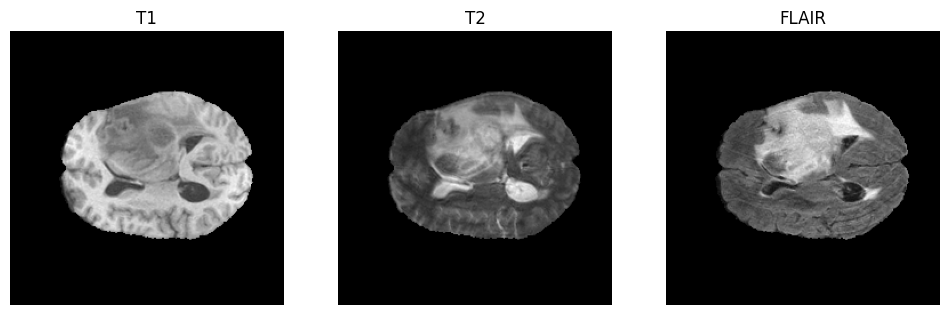

In [19]:
modalities = {
    "T1": "/content/drive/MyDrive/Training_001_t1.nii",
    "T2": "/content/drive/MyDrive/Training_001_t2.nii",
    "FLAIR": "/content/drive/MyDrive/Training_001_flair.nii"
}

plt.figure(figsize=(12,4))

for i, (name, path) in enumerate(modalities.items()):
    img = nib.load(path).get_fdata()
    slice_idx = img.shape[2] // 2

    plt.subplot(1, 3, i+1)
    plt.imshow(img[:, :, slice_idx], cmap='gray')
    plt.title(name)
    plt.axis('off')

plt.show()

In [20]:
import numpy as np

def normalize(volume):
    mean = np.mean(volume)
    std = np.std(volume)
    return (volume - mean) / std

norm_data = normalize(data)

print("Mean:", np.mean(norm_data))
print("Std:", np.std(norm_data))

Mean: -6.45702527686795e-16
Std: 0.9999999999999879


In [21]:
def crop_brain(volume, threshold=0):
    coords = np.where(volume > threshold)

    x_min, x_max = coords[0].min(), coords[0].max()
    y_min, y_max = coords[1].min(), coords[1].max()
    z_min, z_max = coords[2].min(), coords[2].max()

    return volume[x_min:x_max, y_min:y_max, z_min:z_max]

cropped = crop_brain(data)

print("Original shape:", data.shape)
print("Cropped shape:", cropped.shape)

Original shape: (240, 240, 155)
Cropped shape: (136, 172, 134)


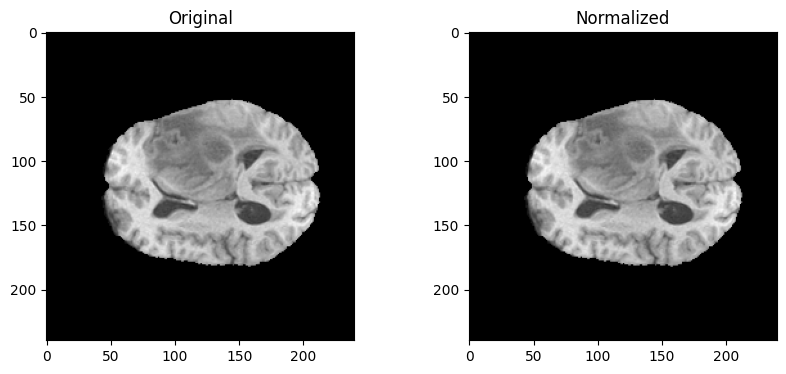

In [22]:
slice_idx = data.shape[2] // 2

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(data[:, :, slice_idx], cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(norm_data[:, :, slice_idx], cmap='gray')
plt.title("Normalized")

plt.show()

In [23]:
!pip install napari

In [24]:
import napari

viewer = napari.Viewer()
viewer.add_image(data)

<Image layer 'data' at 0x7e8e812c1ca0>